In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [40]:
df_E_utt = pd.read_csv("combined_utt_sent_E.csv")
df_T_utt = pd.read_csv("combined_utt_sent_T.csv")
df_M_utt = pd.read_csv("combined_utt_sent_M.csv")

/var/folders/7t/rp_1dcrj5nv_nqhf5_82lk3h0000gn/T/ipykernel_70740/298430867.py:1: DtypeWarning: Columns (0: top_level_comment) have mixed types. Specify dtype option on import or set low_memory=False.
  df_E_utt = pd.read_csv("combined_utt_sent_E.csv")
/var/folders/7t/rp_1dcrj5nv_nqhf5_82lk3h0000gn/T/ipykernel_70740/298430867.py:2: DtypeWarning: Columns (0: top_level_comment) have mixed types. Specify dtype option on import or set low_memory=False.
  df_T_utt = pd.read_csv("combined_utt_sent_T.csv")
/var/folders/7t/rp_1dcrj5nv_nqhf5_82lk3h0000gn/T/ipykernel_70740/298430867.py:3: DtypeWarning: Columns (0: top_level_comment) have mixed types. Specify dtype option on import or set low_memory=False.
  df_M_utt = pd.read_csv("combined_utt_sent_M.csv")


In [41]:
df_M_utt.shape[0] + df_T_utt.shape[0] + df_E_utt.shape[0]

840380

### Confidence Distribution


Percentage:
 bert_label
Positive    34.80416
Neutral     34.64855
Negative    30.54729
Name: proportion, dtype: float64
(272066, 17) (131740, 17)
48.42% of posts

=== Confidence Score Stats ===
count    272066.000000
mean          0.700109
std           0.159539
min           0.337360
25%           0.561496
50%           0.691323
75%           0.834839
max           0.993638
Name: bert_score, dtype: float64


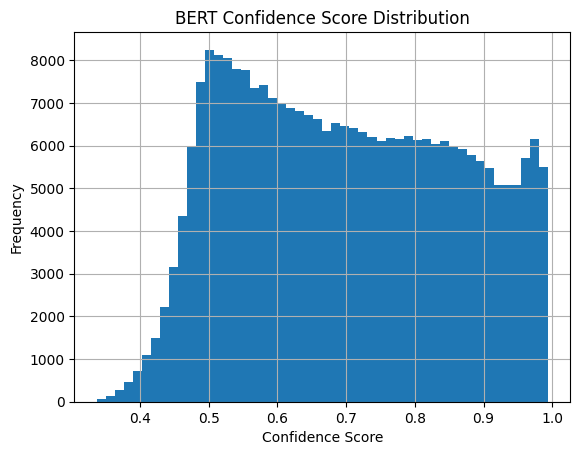

In [ ]:
# Pull High confidence Sentiments

high_conf_df_E = df_E_utt[df_E_utt["bert_score"] > 0.7]
roBERTa_percent_E_HC = high_conf_df_E["bert_label"].value_counts(normalize=True) * 100
print("\nPercentage:\n", roBERTa_percent_E_HC)

print(df_E_utt.shape, high_conf_df_E.shape)
print(f"{round((high_conf_df_E.shape[0] / df_E_utt.shape[0]) * 100, 2)}% of posts")

print("\n=== Confidence Score Stats ===")
print(df_E_utt["bert_score"].describe())

plt.figure()
df_E_utt["bert_score"].hist(bins=50)
plt.title(f"BERT Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()


Percentage:
 bert_label
Neutral     35.965094
Negative    33.585958
Positive    30.448949
Name: proportion, dtype: float64
(285418, 17) (140261, 17)
49.14% of posts

=== Confidence Score Stats ===
count    285418.000000
mean          0.701199
std           0.157842
min           0.335498
25%           0.564464
50%           0.695266
75%           0.835745
max           0.994048
Name: bert_score, dtype: float64


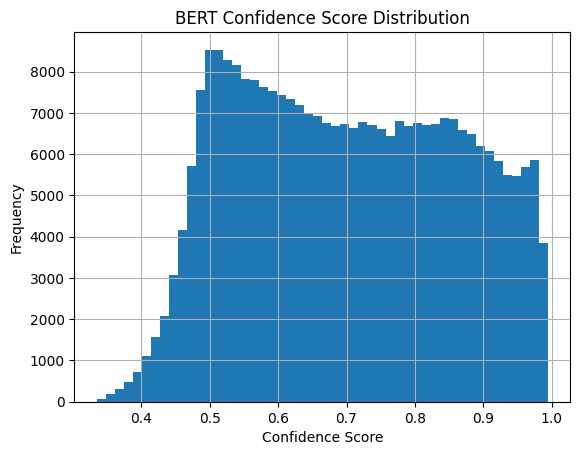

In [ ]:
# Pull High confidence Sentiments

high_conf_df_T = df_T_utt[df_T_utt["bert_score"] > 0.7]
roBERTa_percent_T_HC = high_conf_df_T["bert_label"].value_counts(normalize=True) * 100
print("\nPercentage:\n", roBERTa_percent_T_HC)

print(df_T_utt.shape, high_conf_df_T.shape)
print(f"{round((high_conf_df_T.shape[0] / df_T_utt.shape[0]) * 100, 2)}% of posts")

print("\n=== Confidence Score Stats ===")
print(df_T_utt["bert_score"].describe())

plt.figure()
df_T_utt["bert_score"].hist(bins=50)
plt.title(f"BERT Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()


Percentage:
 bert_label
Negative    36.868604
Positive    31.590979
Neutral     31.540417
Name: proportion, dtype: float64
(282896, 17) (140423, 17)
49.64% of posts

=== Confidence Score Stats ===
count    282896.000000
mean          0.704057
std           0.161788
min           0.333727
25%           0.563200
50%           0.697881
75%           0.843029
max           0.993761
Name: bert_score, dtype: float64


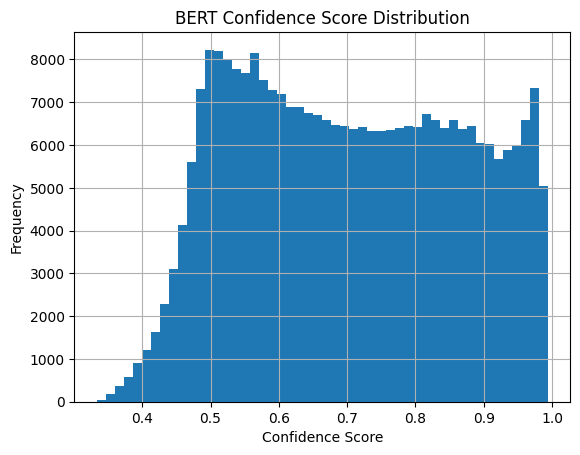

In [ ]:
high_conf_df_M = df_M_utt[df_M_utt["bert_score"] > 0.7]
roBERTa_percent_M_HC = high_conf_df_M["bert_label"].value_counts(normalize=True) * 100
print("\nPercentage:\n", roBERTa_percent_M_HC)

print(df_M_utt.shape, high_conf_df_M.shape)
print(f"{round((high_conf_df_M.shape[0] / df_M_utt.shape[0]) * 100, 2)}% of posts")

print("\n=== Confidence Score Stats ===")
print(df_M_utt["bert_score"].describe())

plt.figure()
df_M_utt["bert_score"].hist(bins=50)
plt.title(f"BERT Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()

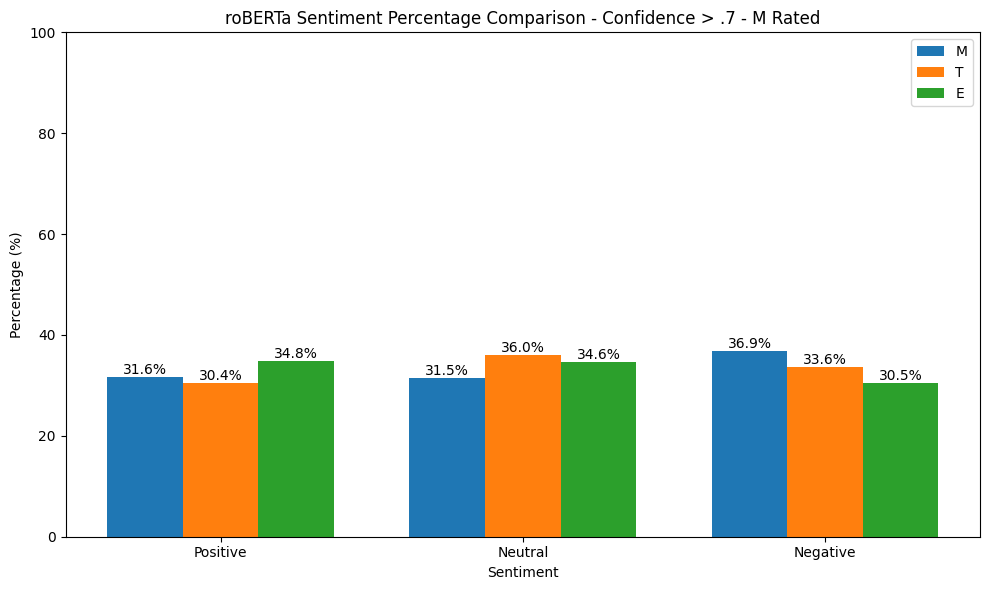

In [ ]:
labels = ['Positive', 'Neutral', 'Negative']
x = np.arange(len(labels))
width = 0.25

percent1 = roBERTa_percent_M_HC.reindex(labels)
percent2 = roBERTa_percent_T_HC.reindex(labels)
percent3 = roBERTa_percent_E_HC.reindex(labels)

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width, percent1.values, width, label="M")
bars2 = plt.bar(x, percent2.values, width, label="T")
bars3 = plt.bar(x + width, percent3.values, width, label="E")

for i in range(len(labels)):
    plt.text(x[i] - width, percent1.values[i], f"{percent1.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i], percent2.values[i], f"{percent2.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i] + width, percent3.values[i], f"{percent3.values[i]:.1f}%", ha='center', va='bottom')

plt.xticks(x, labels)

plt.title(f"roBERTa Sentiment Percentage Comparison - Confidence > .7")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()